# GPU Profiling: Base vs Control vs Runtime-Aware

Profiles all three models with the same setup (same hardware, batch size, and input) using PyTorch Profiler.
Fine-tuned adapters are merged into the base model before profiling.

In [25]:
import os
import sys
import subprocess
from pathlib import Path

PROJECT_ROOT = Path(os.environ.get('EFFICIENT_CODEGEN_ROOT', '/workspace/efficient-codegen'))
os.chdir(PROJECT_ROOT)

BASE_MODEL      = 'Qwen/Qwen2.5-Coder-1.5B-Instruct'
CONTROL_ADAPTER = str(PROJECT_ROOT / 'checkpoints/control_full')
RUNTIME_ADAPTER = str(PROJECT_ROOT / 'checkpoints/runtime_aware_full')

CONTROL_MERGED  = str(PROJECT_ROOT / 'checkpoints/control_full_merged')
RUNTIME_MERGED  = str(PROJECT_ROOT / 'checkpoints/runtime_aware_full_merged')

PROFILE_INPUT   = 'data/curated/scale1k/dataset_clean.json'
BATCH_SIZE      = 64
MAX_NEW_TOKENS  = 128
LIMIT           = 320

OP_PROFILE_LIMIT      = 1   # 1 batch — enough for stable operator stats
OP_MAX_NEW_TOKENS     = 64  # operator distribution converges quickly
OP_PROFILE_BATCH_SIZE = 1   # batch=1 captures decode memory-bound behaviour

WANDB_PROJECT   = 'hpml-efficient-codegen'
WANDB_ENTITY    = 'efficient-codegen'
USE_WANDB       = True

print('PROJECT_ROOT:', PROJECT_ROOT)
print('BASE_MODEL:  ', BASE_MODEL)
print('CONTROL_ADAPTER:', CONTROL_ADAPTER)
print('RUNTIME_ADAPTER:', RUNTIME_ADAPTER)
print('USE_WANDB:', USE_WANDB)


PROJECT_ROOT: /workspace/efficient-codegen
BASE_MODEL:   Qwen/Qwen2.5-Coder-1.5B-Instruct
CONTROL_ADAPTER: /workspace/efficient-codegen/checkpoints/control_full
RUNTIME_ADAPTER: /workspace/efficient-codegen/checkpoints/runtime_aware_full
USE_WANDB: True


In [2]:
import wandb
import os

os.environ["WANDB_API_KEY"] = "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"  # paste your key here, or set it as an env var
if os.environ.get("WANDB_API_KEY"):
    wandb.login(key=os.environ["WANDB_API_KEY"])
else:
    os.environ.setdefault("WANDB_MODE", "disabled")
    USE_WANDB = False
    print("WANDB_API_KEY not set — W&B logging disabled.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yz3202 (efficient-codegen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Step 1: Merge LoRA Adapters

Fine-tuned checkpoints are LoRA adapters — merge them into the base model weights before profiling.
Skip if merged checkpoints already exist.

In [3]:
def merge_adapter(adapter_path, output_dir):
    if Path(output_dir).exists():
        print(f'Already merged: {output_dir}')
        return
    print(f'Merging {adapter_path} -> {output_dir}')
    subprocess.run([
        sys.executable, 'serving/merge_checkpoint.py',
        '--adapter_path',    adapter_path,
        '--base_model_name', BASE_MODEL,
        '--output_dir',      output_dir,
    ], check=True)
    print('Done.')

merge_adapter(CONTROL_ADAPTER, CONTROL_MERGED)
merge_adapter(RUNTIME_ADAPTER, RUNTIME_MERGED)

Already merged: /workspace/efficient-codegen/checkpoints/control_full_merged
Already merged: /workspace/efficient-codegen/checkpoints/runtime_aware_full_merged


## Step 2: Profile Each Model

Runs `profile_model.py` for each model with identical settings.
Traces are saved to `outputs/gpu_profiling/<model>/`.

In [5]:
import torch
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Torch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [6]:
MODELS = {
    'base':          BASE_MODEL,
    'control':       CONTROL_MERGED,
    'runtime_aware': RUNTIME_MERGED,
}

In [7]:
TRACE_BASE = PROJECT_ROOT / 'outputs/gpu_profiling'

summaries = {}

for label, model_path in MODELS.items():
    trace_dir = str(TRACE_BASE / label)
    print(f'\n{"="*60}')
    print(f'Profiling: {label}')
    print(f'{"="*60}')
    cmd = [
        sys.executable, 'profiling/profile_model.py',
        '--input_path',     PROFILE_INPUT,
        '--model_name',     model_path,
        '--trace_dir',      trace_dir,
        '--limit',          str(LIMIT),
        '--batch_size',     str(BATCH_SIZE),
        '--max_new_tokens', str(MAX_NEW_TOKENS),
        '--wandb_project',  WANDB_PROJECT,
        '--wandb_entity',   WANDB_ENTITY,
        '--wandb_run_name', f'gpu-profiling-{label}',
    ]
    if USE_WANDB:
        cmd.append('--use_wandb')
    subprocess.run(cmd, check=True)
    summaries[label] = {'trace_dir': trace_dir}



Profiling: base


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: yz3202 (efficient-codegen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /workspace/efficient-codegen/wandb/run-20260507_052009-vrovd9nn
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run gpu-profiling-base
wandb: ⭐️ View project at https://wandb.ai/efficient-codegen/hpml-efficient-codegen
wandb: 🚀 View run at https://wandb.ai/efficient-codegen/hpml-efficient-codegen/runs/vrovd9nn
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:00<00:00, 890.25it/s]
/workspace/efficient-codegen/profiling/profile_model.py:181: UserWarning: Profiler won't be using warmup, this can skew profiler results
  schedule=schedule(wait=0, warmup=0, active=1),
/venv/main/lib/python3.12/site-packages/torch/profiler/pr

[batch 1/5] batch_size=64 input_len=738 output_len=128 latency=7.7300s tok/s=1059.8
[batch 2/5] batch_size=64 input_len=676 output_len=128 latency=6.7349s tok/s=1216.4
[batch 3/5] batch_size=64 input_len=355 output_len=128 latency=6.2323s tok/s=1314.4
[batch 4/5] batch_size=64 input_len=444 output_len=128 latency=6.4078s tok/s=1278.4
[batch 5/5] batch_size=64 input_len=451 output_len=128 latency=6.4764s tok/s=1264.9

Summary:
Average latency:      6.716270286217332
Average input length: 532.8
Average output len:   128.0
Trace directory:      /workspace/efficient-codegen/outputs/gpu_profiling/base
Peak CUDA memory MB:  5589.05


wandb: updating run metadata
wandb: uploading history steps 0-0, summary, console lines 11-18; uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:       avg_input_len ▁
wandb:       avg_latency_s ▁
wandb:      avg_output_len ▁
wandb: peak_cuda_memory_mb ▁
wandb: 
wandb: Run summary:
wandb:       avg_input_len 532.8
wandb:       avg_latency_s 6.71627
wandb:      avg_output_len 128
wandb: peak_cuda_memory_mb 5589.04932
wandb: 
wandb: 🚀 View run gpu-profiling-base at: https://wandb.ai/efficient-codegen/hpml-efficient-codegen/runs/vrovd9nn
wandb: ⭐️ View project at: https://wandb.ai/efficient-codegen/hpml-efficient-codegen
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260507_052009-vrovd9nn/logs



Profiling: control


...

wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading wandb-summary.json
wandb: 
wandb: Run history:
wandb:       avg_input_len ▁
wandb:       avg_latency_s ▁
wandb:      avg_output_len ▁
wandb: peak_cuda_memory_mb ▁
wandb: 
wandb: Run summary:
wandb:       avg_input_len 532.8
wandb:       avg_latency_s 6.6669
wandb:      avg_output_len 128
wandb: peak_cuda_memory_mb 5589.04932
wandb: 
wandb: 🚀 View run gpu-profiling-control at: https://wandb.ai/efficient-codegen/hpml-efficient-codegen/runs/eztnwnqn
wandb: ⭐️ View project at: https://wandb.ai/efficient-codegen/hpml-efficient-codegen
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260507_052217-eztnwnqn/logs



Profiling: runtime_aware


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: yz3202 (efficient-codegen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run 1dv9xvaq
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /workspace/efficient-codegen/wandb/run-20260507_052424-1dv9xvaq
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run gpu-profiling-runtime_aware
wandb: ⭐️ View project at https://wandb.ai/efficient-codegen/hpml-efficient-codegen
wandb: 🚀 View run at https://wandb.ai/efficient-codegen/hpml-efficient-codegen/runs/1dv9xvaq
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:00<00:00, 364.99it/s]
/workspace/efficient-codegen/profiling/profile_model.py:181: UserWarning: Profiler won't be using warmup, this can skew profiler results
  schedule=schedule(wait=0, warmup=0, active=1),
/venv/main/lib/py

[batch 1/5] batch_size=64 input_len=738 output_len=128 latency=7.3582s tok/s=1113.3
[batch 2/5] batch_size=64 input_len=676 output_len=128 latency=6.7392s tok/s=1215.6
[batch 3/5] batch_size=64 input_len=355 output_len=128 latency=6.1833s tok/s=1324.9
[batch 4/5] batch_size=64 input_len=444 output_len=128 latency=6.3186s tok/s=1296.5
[batch 5/5] batch_size=64 input_len=451 output_len=128 latency=6.6133s tok/s=1238.7

Summary:
Average latency:      6.642522533610463
Average input length: 532.8
Average output len:   128.0
Trace directory:      /workspace/efficient-codegen/outputs/gpu_profiling/runtime_aware
Peak CUDA memory MB:  5589.05


wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml; uploading history steps 0-0, summary, console lines 10-17
wandb: uploading config.yaml
wandb: 
wandb: Run history:
wandb:       avg_input_len ▁
wandb:       avg_latency_s ▁
wandb:      avg_output_len ▁
wandb: peak_cuda_memory_mb ▁
wandb: 
wandb: Run summary:
wandb:       avg_input_len 532.8
wandb:       avg_latency_s 6.64252
wandb:      avg_output_len 128
wandb: peak_cuda_memory_mb 5589.04932
wandb: 
wandb: 🚀 View run gpu-profiling-runtime_aware at: https://wandb.ai/efficient-codegen/hpml-efficient-codegen/runs/1dv9xvaq
wandb: ⭐️ View project at: https://wandb.ai/efficient-codegen/hpml-efficient-codegen
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260507_052424-1dv9xvaq/logs


## Step 3: Parse Traces and Compare

In [8]:
import json
from collections import defaultdict
import pandas as pd

TOP_N = 15
REPORT = {}

for label in MODELS:
    trace_dir = TRACE_BASE / label
    trace_files = sorted(trace_dir.rglob('*.pt.trace.json')) if trace_dir.exists() else []
    if not trace_files:
        print(f'No traces found for {label}')
        continue

    trace_file = max(trace_files, key=lambda f: f.stat().st_size)
    print(f'\n[{label}] Parsing: {trace_file.name}')

    with open(trace_file) as f:
        data = json.load(f)

    events = data.get('traceEvents', data) if isinstance(data, dict) else data
    op_time = defaultdict(float)
    op_calls = defaultdict(int)
    total = 0.0
    for e in events:
        if not isinstance(e, dict):
            continue
        if e.get('ph') == 'X' and e.get('dur', 0) > 0:
            name = e.get('name', 'unknown')
            dur_ms = e['dur'] / 1000
            op_time[name] += dur_ms
            op_calls[name] += 1
            total += dur_ms

    top = sorted(op_time.items(), key=lambda x: x[1], reverse=True)[:TOP_N]
    REPORT[label] = {'total_ms': total, 'top_ops': top, 'op_time': op_time, 'op_calls': op_calls}

    print(f"  Total traced time: {total:.2f} ms")
    print(f"  {'Operator':<50} {'ms':>10} {'%':>7}")
    print(f"  {'-'*70}")
    for name, ms in top:
        pct = ms / total * 100
        print(f"  {name:<50} {ms:>10.2f} {pct:>6.1f}%")


[base] Parsing: worker0.1778131323963008726.pt.trace.json
  Total traced time: 37206.14 ms
  Operator                                                   ms       %
  ----------------------------------------------------------------------
  ProfilerStep#4                                       13217.73   35.5%
  PyTorch Profiler (0)                                  6745.83   18.1%
  void at::native::elementwise_kernel<128, 4, at::native::gpu_kernel_impl_nocast<at::native::direct_copy_kernel_cuda(at::TensorIteratorBase&)::{lambda()#3}::operator()() const::{lambda()#12}::operator()() const::{lambda(c10::BFloat16)#1}>(at::TensorIteratorBase&, at::native::direct_copy_kernel_cuda(at::TensorIteratorBase&)::{lambda()#3}::operator()() const::{lambda()#12}::operator()() const::{lambda(c10::BFloat16)#1} const&)::{lambda(int)#1}>(int, at::native::gpu_kernel_impl_nocast<at::native::direct_copy_kernel_cuda(at::TensorIteratorBase&)::{lambda()#3}::operator()() const::{lambda()#12}::operator()() const::{

## Step 4: Side-by-Side Comparison

Top operators compared across all three models.

In [14]:
# Build KEY_OPS from the union of top-N ops across all models
SKIP = {'ProfilerStep#0', 'ProfilerStep#4', 'PyTorch Profiler (0)', 'Runtime Triggered Module Loading'}
seen = {}
for label in MODELS:
    for name, ms in REPORT[label]['top_ops']:
        if name not in SKIP and not name.startswith('void ') and not name.startswith('fmha'):
            seen[name] = seen.get(name, 0) + ms

KEY_OPS = [op for op, _ in sorted(seen.items(), key=lambda x: -x[1])[:12]]

rows = []
for op in KEY_OPS:
    row = {'Operator': op}
    for label in MODELS:
        if label not in REPORT:
            row[f'{label} ms'] = None
            row[f'{label} %'] = None
            continue
        ms = REPORT[label]['op_time'].get(op, 0.0)
        pct = ms / REPORT[label]['total_ms'] * 100
        row[f'{label} ms'] = round(ms, 2)
        row[f'{label} %'] = round(pct, 2)
    rows.append(row)

df = pd.DataFrame(rows).set_index('Operator')
print('Key Operator Comparison (ms and % of total traced time)')
print('=' * 80)
df

Key Operator Comparison (ms and % of total traced time)


,base ms,base %,control ms,control %,runtime_aware ms,runtime_aware %
Operator,,,,,,
aten::linear,1203.62,3.24,1222.84,3.26,1242.36,3.28
cudaLaunchKernel,1166.64,3.14,1187.18,3.17,1207.50,3.19
aten::is_nonzero,724.94,1.95,726.43,1.94,719.45,1.90
aten::item,724.87,1.95,726.36,1.94,719.38,1.90
aten::_local_scalar_dense,724.05,1.95,725.72,1.94,718.74,1.90
cudaStreamSynchronize,720.69,1.94,722.20,1.93,715.30,1.89
aten::scaled_dot_product_attention,580.42,1.56,580.46,1.55,588.01,1.55
aten::matmul,562.82,1.51,574.10,1.53,588.32,1.55
aten::mul,461.72,1.24,470.36,1.26,477.61,1.26


## Step 5: Operator-Level Profiling

Runs `profile_operators.py` for each model, producing a bottleneck report and CSV of operator times.
Output is saved to `outputs/operator_profiling/<model>/`.

In [28]:
OP_PROFILE_BASE = PROJECT_ROOT / 'outputs/operator_profiling'

tmp_dir = '/workspace/efficient-codegen/tmp'
os.makedirs(tmp_dir, exist_ok=True)
env = os.environ.copy()
env['TMPDIR'] = tmp_dir

# A100 SXM4-40GB hardware specs for roofline model
GPU_NAME = 'A100 SXM4-40GB'
GPU_PEAK_TFLOPS = 312.0      # BF16 Tensor Core peak
GPU_PEAK_BW_GBS = 1555.0     # HBM2e peak bandwidth (GB/s)

for label, model_path in MODELS.items():
    output_dir = str(OP_PROFILE_BASE / label)
    print(f'\n{"="*60}')
    print(f'Operator profiling: {label}')
    print(f'{"="*60}')
    subprocess.run([
        sys.executable, 'profiling/profile_operators.py',
        '--input_path',              PROFILE_INPUT,
        '--model_name',              model_path,
        '--limit',                   str(OP_PROFILE_LIMIT),
        '--batch_size',              str(OP_PROFILE_BATCH_SIZE),
        '--max_new_tokens',          str(OP_MAX_NEW_TOKENS),
        '--output_dir',              output_dir,
        '--gpu_name',                GPU_NAME,
        '--gpu_peak_tflops',         str(GPU_PEAK_TFLOPS),
        '--gpu_peak_bandwidth_gbs',  str(GPU_PEAK_BW_GBS),
    ], check=True, env=env)



Operator profiling: base
Device : cuda  |  dtype : torch.bfloat16
Output : /workspace/efficient-codegen/outputs/operator_profiling/base


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:00<00:00, 912.94it/s]



Warming up...

Profiling 1 example(s) in 1 batch(es) of 1...



/venv/main/lib/python3.12/site-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


[batch 1/1]  bs=1  in=327  out=64  latency=2.662s  tok/s=24.0

Chrome trace → /workspace/efficient-codegen/outputs/operator_profiling/base/chrome_trace.json
Operator CSV → /workspace/efficient-codegen/outputs/operator_profiling/base/operators.csv
Bottleneck report → /workspace/efficient-codegen/outputs/operator_profiling/base/bottleneck_report.txt
Roofline report → /workspace/efficient-codegen/outputs/operator_profiling/base/roofline_report.txt
Roofline plot saved → /workspace/efficient-codegen/outputs/operator_profiling/base/roofline.png

TensorBoard: tensorboard --logdir /workspace/efficient-codegen/outputs/operator_profiling/base/tb_trace

Operator profiling: control
Device : cuda  |  dtype : torch.bfloat16
Output : /workspace/efficient-codegen/outputs/operator_profiling/control


...

[batch 1/1]  bs=1  in=327  out=64  latency=2.726s  tok/s=23.5

Chrome trace → /workspace/efficient-codegen/outputs/operator_profiling/control/chrome_trace.json
Operator CSV → /workspace/efficient-codegen/outputs/operator_profiling/control/operators.csv
Bottleneck report → /workspace/efficient-codegen/outputs/operator_profiling/control/bottleneck_report.txt
Roofline report → /workspace/efficient-codegen/outputs/operator_profiling/control/roofline_report.txt
Roofline plot saved → /workspace/efficient-codegen/outputs/operator_profiling/control/roofline.png

TensorBoard: tensorboard --logdir /workspace/efficient-codegen/outputs/operator_profiling/control/tb_trace

Operator profiling: runtime_aware
Device : cuda  |  dtype : torch.bfloat16
Output : /workspace/efficient-codegen/outputs/operator_profiling/runtime_aware


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:00<00:00, 692.46it/s]



Warming up...

Profiling 1 example(s) in 1 batch(es) of 1...



/venv/main/lib/python3.12/site-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


[batch 1/1]  bs=1  in=327  out=64  latency=2.656s  tok/s=24.1

Chrome trace → /workspace/efficient-codegen/outputs/operator_profiling/runtime_aware/chrome_trace.json
Operator CSV → /workspace/efficient-codegen/outputs/operator_profiling/runtime_aware/operators.csv
Bottleneck report → /workspace/efficient-codegen/outputs/operator_profiling/runtime_aware/bottleneck_report.txt
Roofline report → /workspace/efficient-codegen/outputs/operator_profiling/runtime_aware/roofline_report.txt
Roofline plot saved → /workspace/efficient-codegen/outputs/operator_profiling/runtime_aware/roofline.png

TensorBoard: tensorboard --logdir /workspace/efficient-codegen/outputs/operator_profiling/runtime_aware/tb_trace


## Step 6: Operator Bottleneck Reports

In [29]:
for label in MODELS:
    report = OP_PROFILE_BASE / label / 'bottleneck_report.txt'
    if report.exists():
        print(f'\n{"="*60}')
        print(f'  {label}')
        print(f'{"="*60}')
        print(report.read_text(encoding='utf-8')[:3000])
    else:
        print(f'No report found for {label}')



  base
OPERATOR-LEVEL BOTTLENECK REPORT

Top 30 operators by CPU self-time:

Operator                                                   CUDA ms     CPU ms    Calls  % total
-----------------------------------------------------------------------------------------------
full_generate                                                0.000   2662.268        1    28.2%
decode_remaining                                             0.000   2229.574       58    23.6%
aten::linear                                                 0.000    623.538    12608     6.6%
cudaLaunchKernel                                             0.000    517.828    80967     5.5%
aten::matmul                                                 0.000    278.160     7296     2.9%
aten::mul                                                    0.000    233.500    16384     2.5%
aten::addmm                                                  0.000    210.292     5376     2.2%
aten::mm                                                  

## Step 7: Operator CSV Comparison

Loads `operators.csv` from each model run and shows a side-by-side comparison of top operators by CPU time.

In [30]:
import pandas as pd

op_dfs = {}
for label in MODELS:
    csv_path = OP_PROFILE_BASE / label / 'operators.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        op_dfs[label] = df.set_index('operator') if 'operator' in df.columns else df
    else:
        print(f'No operators.csv for {label}')

if op_dfs:
    col = 'cpu_time_ms'
    top_ops = (
        pd.concat({k: v[col] for k, v in op_dfs.items() if col in v.columns}, axis=1)
        .fillna(0)
        .assign(total=lambda d: d.sum(axis=1))
        .sort_values('total', ascending=False)
        .drop(columns='total')
        .head(20)
    )
    print('Top 20 operators by CPU time (ms)')
    print('=' * 60)
    display(top_ops)


Top 20 operators by CPU time (ms)


,base,control,runtime_aware
operator,,,
full_generate,2662.2682,2725.8203,2655.6402
decode_remaining,2229.5741,2289.4940,2225.3845
aten::linear,623.5376,639.7915,622.3281
cudaLaunchKernel,517.8281,529.8133,513.0981
aten::matmul,278.1604,285.6501,276.9544
aten::mul,233.4999,239.8730,232.6218
aten::addmm,210.2922,216.0314,211.8309
aten::mm,192.9064,197.4164,191.9613
aten::to,179.7248,186.3572,179.0064


## Step 8: Roofline Analysis

Reads `roofline_report.txt` and displays `roofline.png` for each model.
Each operator is classified as compute-bound (AI ≥ ridge point) or memory-bound (AI < ridge point).
The ridge point for the A100 SXM4-40GB is 312 TFLOPs / 1555 GB/s ≈ **200 FLOPs/byte**.


  base
ROOFLINE ANALYSIS
  GPU              : A100 SXM4-40GB
  Peak compute     : 312 TFLOPs/s
  Peak bandwidth   : 1555 GB/s
  Ridge point      : 200.6 FLOPs/byte
  Timing source    : cpu_time_total (CUDA times unavailable in this PyTorch build)
  Memory bytes src : analytical (36 ops), allocation proxy (0), ridge fallback (0).
                     For hardware-accurate values use NVIDIA Nsight Compute.

  16 memory-bound op(s)  |  20 compute-bound op(s)

  Time in memory-bound ops :     13.2 ms  (1.7%)
  Time in compute-bound ops:    781.2 ms  (98.3%)

  Effective arithmetic intensity : 991.3 FLOPs/byte
  Ridge point                   : 200.6 FLOPs/byte
  Overall workload              : COMPUTE-BOUND

  Operator                                        AI (F/B)   GFLOPs/s          Bound   CUDA ms          Mem src
  -------------------------------------------------------------------------------------------------------------
  aten::addmm                                      3509.72    

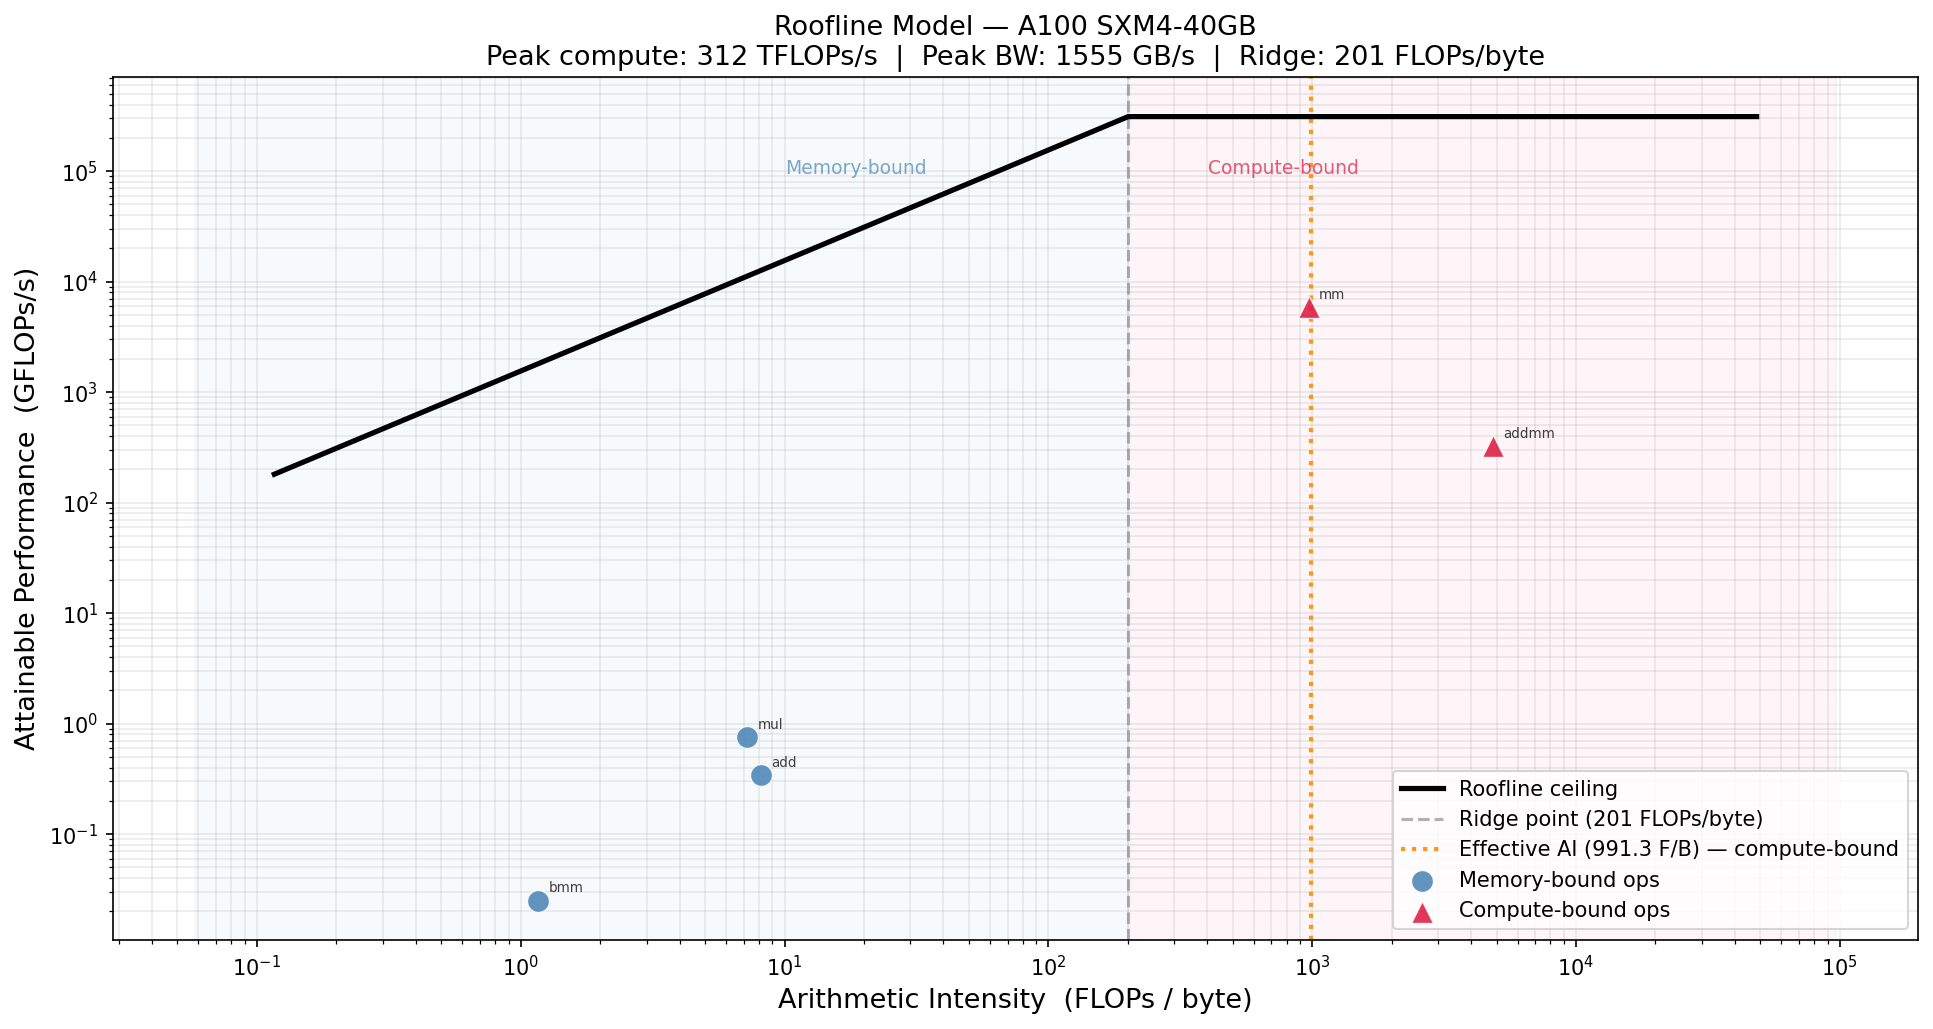


  control
ROOFLINE ANALYSIS
  GPU              : A100 SXM4-40GB
  Peak compute     : 312 TFLOPs/s
  Peak bandwidth   : 1555 GB/s
  Ridge point      : 200.6 FLOPs/byte
  Timing source    : cpu_time_total (CUDA times unavailable in this PyTorch build)
  Memory bytes src : analytical (36 ops), allocation proxy (0), ridge fallback (0).
                     For hardware-accurate values use NVIDIA Nsight Compute.

  16 memory-bound op(s)  |  20 compute-bound op(s)

  Time in memory-bound ops :     13.1 ms  (1.6%)
  Time in compute-bound ops:    802.8 ms  (98.4%)

  Effective arithmetic intensity : 991.3 FLOPs/byte
  Ridge point                   : 200.6 FLOPs/byte
  Overall workload              : COMPUTE-BOUND

  Operator                                        AI (F/B)   GFLOPs/s          Bound   CUDA ms          Mem src
  -------------------------------------------------------------------------------------------------------------
  aten::addmm                                      3509.72 

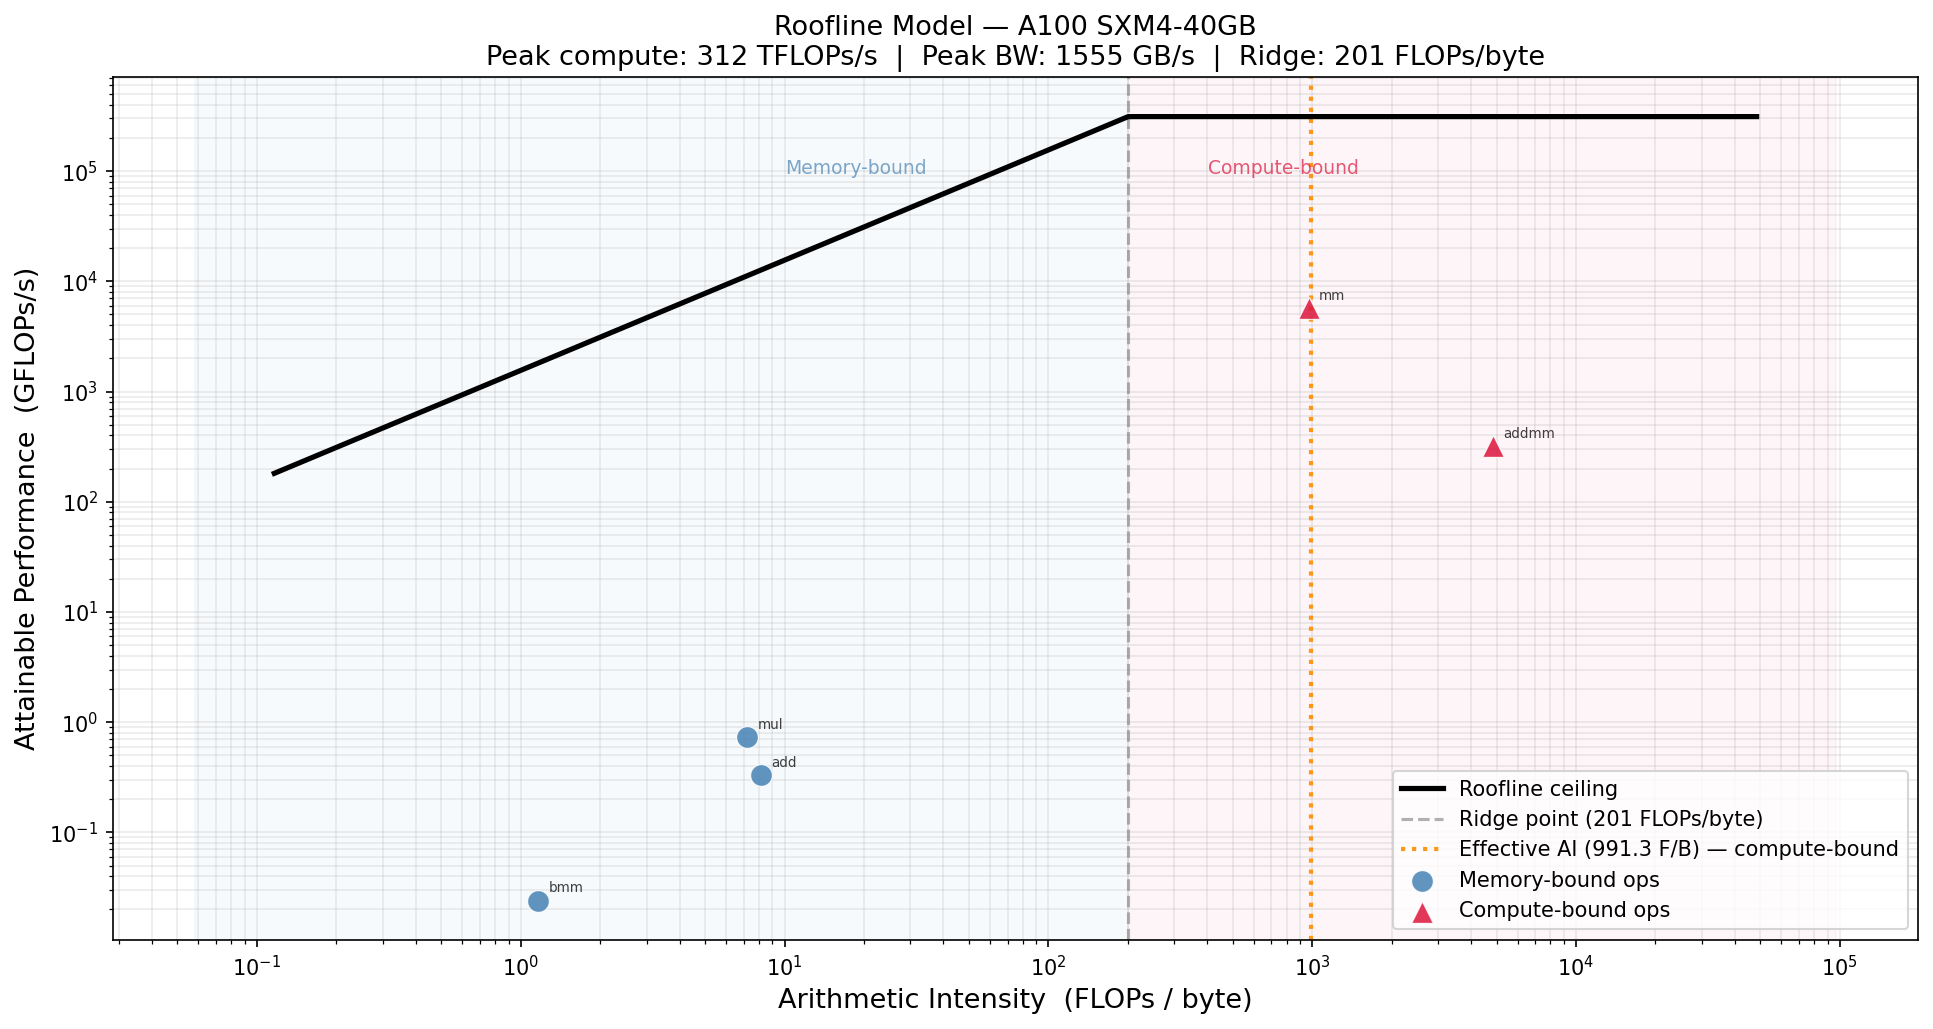


  runtime_aware
ROOFLINE ANALYSIS
  GPU              : A100 SXM4-40GB
  Peak compute     : 312 TFLOPs/s
  Peak bandwidth   : 1555 GB/s
  Ridge point      : 200.6 FLOPs/byte
  Timing source    : cpu_time_total (CUDA times unavailable in this PyTorch build)
  Memory bytes src : analytical (36 ops), allocation proxy (0), ridge fallback (0).
                     For hardware-accurate values use NVIDIA Nsight Compute.

  16 memory-bound op(s)  |  20 compute-bound op(s)

  Time in memory-bound ops :     13.4 ms  (1.7%)
  Time in compute-bound ops:    781.6 ms  (98.3%)

  Effective arithmetic intensity : 991.3 FLOPs/byte
  Ridge point                   : 200.6 FLOPs/byte
  Overall workload              : COMPUTE-BOUND

  Operator                                        AI (F/B)   GFLOPs/s          Bound   CUDA ms          Mem src
  -------------------------------------------------------------------------------------------------------------
  aten::addmm                                      35

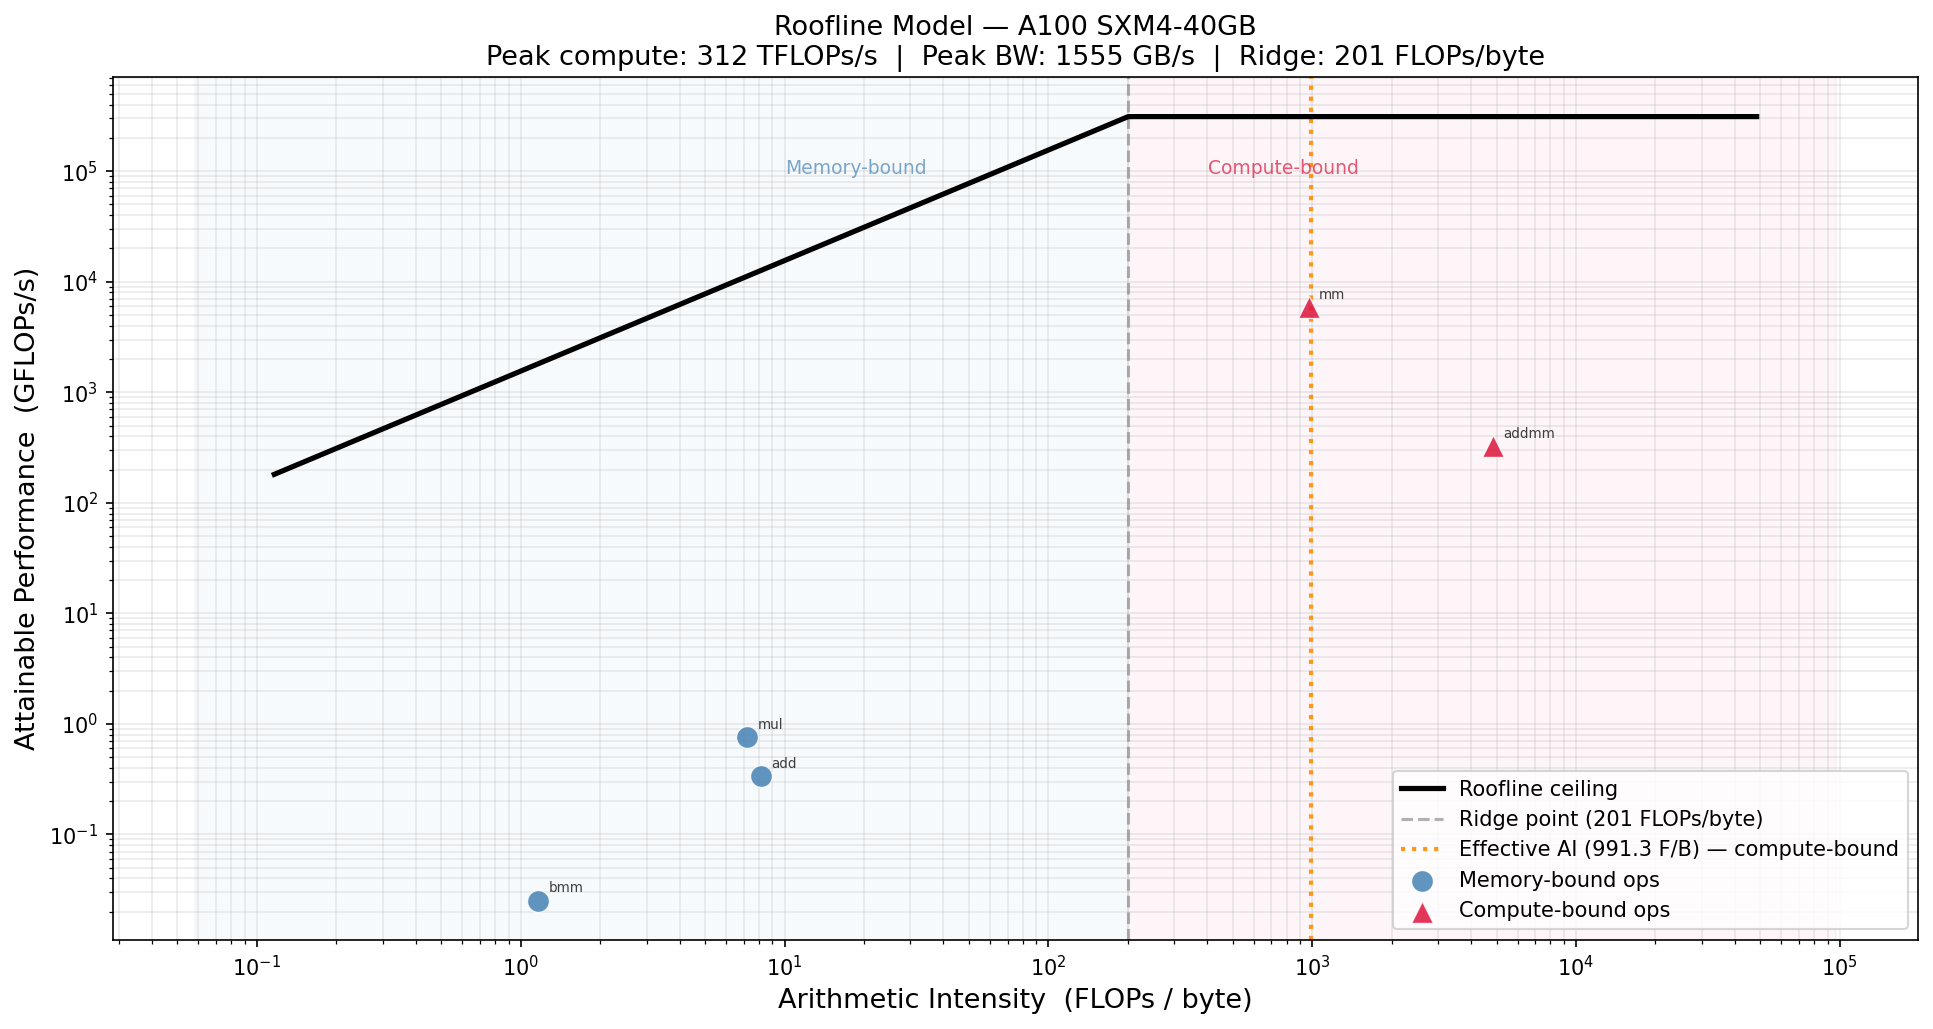

In [31]:
from IPython.display import Image, display

for label in MODELS:
    report_path = OP_PROFILE_BASE / label / 'roofline_report.txt'
    plot_path   = OP_PROFILE_BASE / label / 'roofline.png'

    print(f'\n{"="*60}')
    print(f'  {label}')
    print(f'{"="*60}')

    if report_path.exists():
        print(report_path.read_text(encoding='utf-8'))
    else:
        print('  roofline_report.txt not found — re-run Step 6.')

    if plot_path.exists():
        display(Image(filename=str(plot_path)))
    else:
        print('  roofline.png not found — re-run Step 6.')
